In [18]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.linear_model import LinearRegression
from statsmodels.graphics.tsaplots import plot_pacf

sns.set_theme(style="whitegrid", palette="deep")

In [2]:
data_dir = Path("./data/")

df = pd.read_csv(
    data_dir / "ED18_03112023.csv",
    index_col="datetime",
    parse_dates=["datetime"],
).drop(
    [
        "_id",
        "unit_id",
        "rounded_datatime",
    ],
    axis=1,
)

# equivalent but more verbose: df = ed18_data.loc[:, "TotVA"].to_frame() 
df = df[["TotVA"]]

print(f'Dropping NaN {df.loc[:, "TotVA"].isna().sum()} values.')
df = df.dropna()

Dropping NaN 174 values.


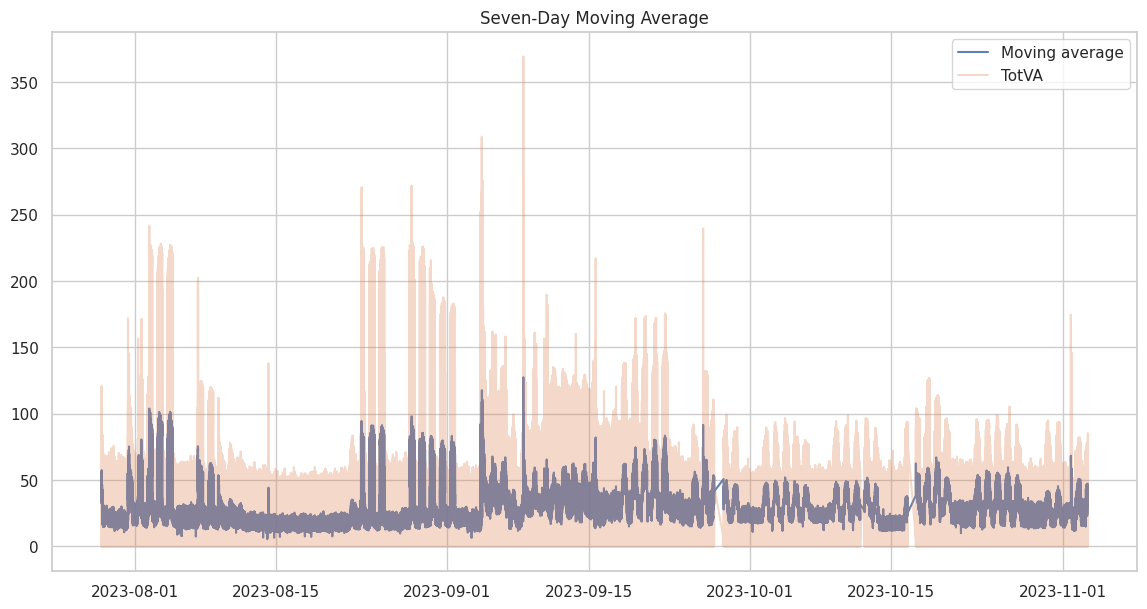

In [17]:
y_ma = df.rolling(
    window=7,
    center=True,
).mean()


fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(y_ma, color="C0", alpha=0.9)
ax.plot(df["TotVA"], color="C1", alpha=0.3)
ax.set_title("Seven-Day Moving Average");
ax.legend(["Moving average", "TotVA"])

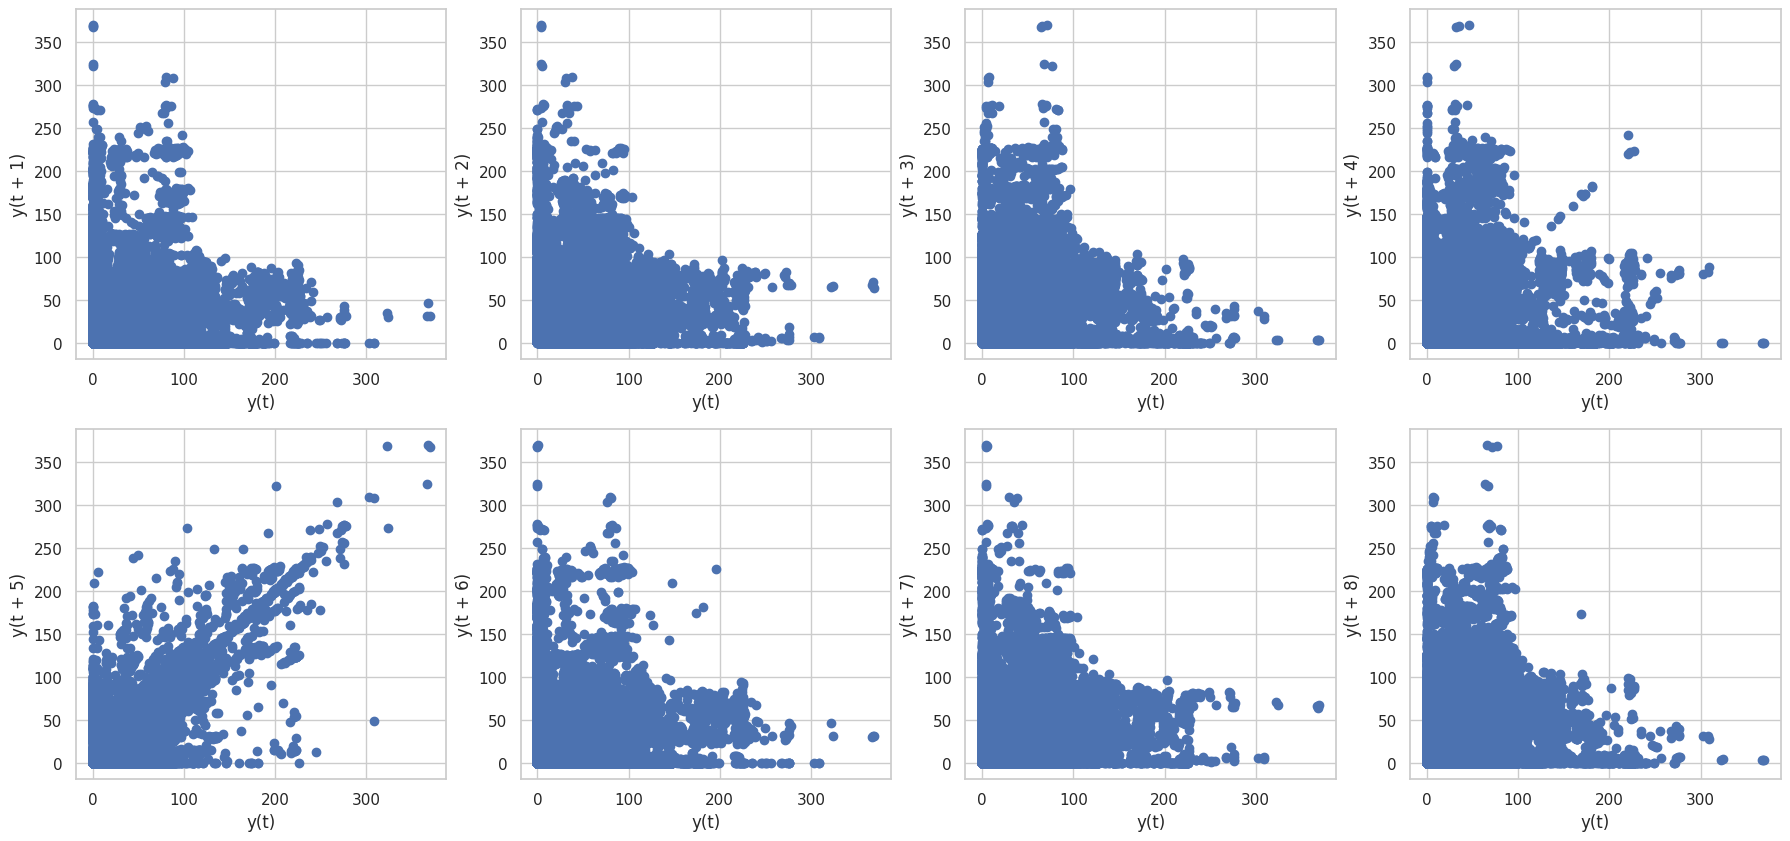

In [64]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 10))
axes = list(axes[0]) + list(axes[1])
lags = [i for i in range(1, 9)]
for ax, lag in zip(axes, lags):
    pd.plotting.lag_plot(df["TotVA"], lag=lag, ax=ax)

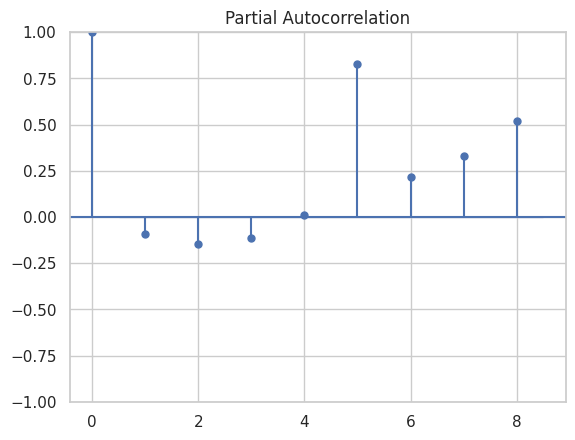

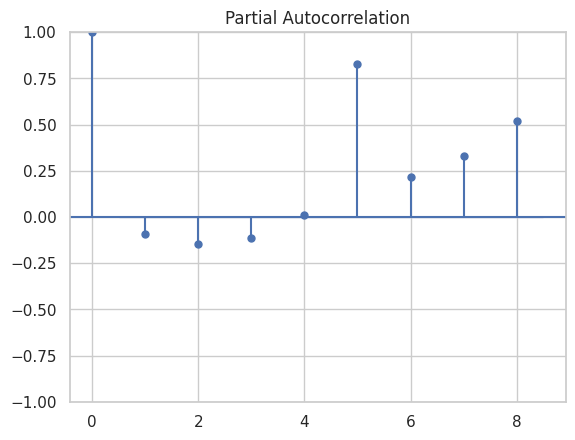

In [68]:
plot_pacf(df, lags=8)